In [2]:
import pandas as pd
import requests
import time
import os
from datetime import datetime

start_season = 2010
end_season = 2026

output_dir = "Barttorvik_Daily_Scrapes"
os.makedirs(output_dir, exist_ok=True)

# A manual override dictionary to skip the empty early-season months
custom_start_dates = {
    2010: "2010-02-15",
    2011: "2011-01-15",
    2012: "2011-12-15",
    2013: "2012-12-01",
    2014: "2013-12-01"
}

print("Starting the Speed-Optimized Mega-Scrape...")

for season in range(start_season, end_season + 1):
    print(f"\n=====================================")
    print(f"  STARTING SEASON: {season}")
    print(f"=====================================")

    season_data = []
    start_date = custom_start_dates.get(season, f"{season - 1}-11-15")
    end_date = f"{season}-04-10"
    date_range = pd.date_range(start=start_date, end=end_date)

    print(f"  -> Skipping straight to {start_date}...")

    for dt in date_range:
        date_str = dt.strftime('%Y%m%d')
        url = f"https://barttorvik.com/timemachine/team_results/{date_str}_team_results.json.gz"

        try:
            headers = {'User-Agent': 'Mozilla/5.0'}
            response = requests.get(url, headers=headers)
            response.raise_for_status()

            data = response.json()
            df = pd.DataFrame(data)
            df['Date'] = dt.strftime('%Y-%m-%d')
            df['Season'] = season

            season_data.append(df)
            print(f"  [+] {date_str} - Success! ({len(df)} teams)")

        except ValueError:
            pass
        except requests.exceptions.HTTPError:
            pass
        except Exception as e:
            print(f"  [!] Connection issue on {date_str}: {e}")

        time.sleep(1)

    if season_data:
        season_df = pd.concat(season_data, ignore_index=True)
        filename = f"{output_dir}/barttorvik_daily_{season}.csv"
        season_df.to_csv(filename, index=False)
        print(f">>> Saved {season} to {filename} ({len(season_df)} total rows)")
    else:
        print(f">>> WARNING: No data was collected for {season}")

print("\nAll seasons complete! Check the 'Barttorvik_Daily_Scrapes' folder.")

Starting the Speed-Optimized Mega-Scrape...

  STARTING SEASON: 2010
  -> Skipping straight to 2010-02-15...
  [+] 20100215 - Success! (347 teams)
  [+] 20100216 - Success! (347 teams)
  [+] 20100217 - Success! (347 teams)
  [+] 20100218 - Success! (347 teams)
  [+] 20100219 - Success! (347 teams)
  [+] 20100220 - Success! (347 teams)
  [+] 20100221 - Success! (347 teams)
  [+] 20100222 - Success! (347 teams)


KeyboardInterrupt: 

In [7]:
import pandas as pd
import os
import glob

# 1. Load the Kaggle spelling file
spellings_df = pd.read_csv('MTeamSpellings.csv', encoding='latin-1')

# 2. Define our custom translation dictionary for the Barttorvik names
manual_mapping = {
    'texas a&m corpus chris': 'a&m-corpus christi',
    'illinois chicago': 'illinois-chicago',
    'queens': 'queens (nc)',
    'southeast missouri st.': 'southeast missouri state',
    'ut rio grande valley': 'texas-rio grande valley',
    'cal st. bakersfield': 'cal state bakersfield',
    'tarleton st.': 'tarleton state',
    'tennessee martin': 'tennessee-martin',
    'bethune cookman': 'bethune-cookman',
    'saint francis': 'saint francis (pa)',
    'texas a&m commerce': 'texas a&m-commerce',
    'louisiana monroe': 'louisiana-monroe',
    'arkansas pine bluff': 'arkansas-pine bluff',
    'mississippi valley st.': 'mississippi valley state',
    'louisiana lafayette': 'louisiana-lafayette',
    'st. francis pa': 'st francis pa',
    'st. francis ny': 'st francis ny',
    'dixie st.': 'dixie state',
    'arkansas little rock': 'arkansas-little rock',
    'winston salem st.': 'winston salem'
}

# 3. Target the custom folder containing your yearly CSV files
scrape_folder = "Bart_yearlies"
file_pattern = os.path.join(scrape_folder, "barttorvik_daily_*.csv")
all_files = glob.glob(file_pattern)

all_mapped_data = []
print(f"Found {len(all_files)} season files in '{scrape_folder}'. Mapping Team IDs and cleaning data...")

for file in all_files:
    print(f"  -> Processing {os.path.basename(file)}...")
    df = pd.read_csv(file)

    # Rename integer string columns to the appropriate features
    if '1' in df.columns:
        df.rename(columns={'1': 'TeamName'}, inplace=True)

    rename_cols = {'4': 'AdjO', '6': 'AdjD', '8': 'Barthag'}
    df.rename(columns={k: v for k, v in rename_cols.items() if k in df.columns}, inplace=True)

    # Standardize names for merging
    df['TeamNameSpelling'] = df['TeamName'].str.lower().str.strip()
    df['TeamNameSpelling'] = df['TeamNameSpelling'].replace(manual_mapping)

    # Merge with Kaggle IDs
    merged_df = pd.merge(df, spellings_df, on='TeamNameSpelling', how='left')
    merged_df.dropna(subset=['TeamID'], inplace=True)
    merged_df['TeamID'] = merged_df['TeamID'].astype(int)

    # Keep only what we need
    cols_to_keep = ['Date', 'Season', 'TeamID', 'TeamName', 'AdjO', 'AdjD', 'Barthag']
    final_cols = [c for c in cols_to_keep if c in merged_df.columns]
    
    mapped_season_df = merged_df[final_cols]
    all_mapped_data.append(mapped_season_df)

if all_mapped_data:
    master_daily_df = pd.concat(all_mapped_data, ignore_index=True)
    output_file = 'barttorvik_daily_master_with_ids.csv'
    master_daily_df.to_csv(output_file, index=False)
    print(f"\nSUCCESS! Massive daily dataset saved as '{output_file}'.")
else:
    print("\n[!] ERROR: No files were processed.")
    print("Check that the 'Bart_yearlies' folder is exactly in the same directory as this notebook, and that it contains your CSVs.")

Found 17 season files in 'Bart_yearlies'. Mapping Team IDs and cleaning data...
  -> Processing barttorvik_daily_2025.csv...
  -> Processing barttorvik_daily_2018.csv...
  -> Processing barttorvik_daily_2026.csv...
  -> Processing barttorvik_daily_2013.csv...
  -> Processing barttorvik_daily_2023.csv...
  -> Processing barttorvik_daily_2022.csv...
  -> Processing barttorvik_daily_2014.csv...
  -> Processing barttorvik_daily_2019.csv...
  -> Processing barttorvik_daily_2015.csv...
  -> Processing barttorvik_daily_2010.csv...
  -> Processing barttorvik_daily_2012.csv...
  -> Processing barttorvik_daily_2017.csv...
  -> Processing barttorvik_daily_2016.csv...
  -> Processing barttorvik_daily_2011.csv...
  -> Processing barttorvik_daily_2024.csv...
  -> Processing barttorvik_daily_2020.csv...
  -> Processing barttorvik_daily_2021.csv...

SUCCESS! Massive daily dataset saved as 'barttorvik_daily_master_with_ids.csv'.


In [3]:
import pandas as pd
import numpy as np

print("Loading datasets...")
games = pd.read_csv('MRegularSeasonDetailedResults.csv')
massey = pd.read_csv('MMasseyOrdinals.csv')

# PHASE 1: PREP THE RANKINGS
print("Filtering Massey Ordinals for RPI and NET...")
massey['TargetSystem'] = np.where(massey['Season'] >= 2019, 'NET', 'RPI')
massey_filtered = massey[massey['SystemName'] == massey['TargetSystem']].copy()
massey_filtered.sort_values(['Season', 'TeamID', 'RankingDayNum'], inplace=True)

# PHASE 2: RESTRUCTURE GAMES
print("Restructuring games into a team-centric format...")
winners = games[['Season', 'DayNum', 'WTeamID', 'LTeamID', 'WLoc']].copy()
winners.rename(columns={'WTeamID': 'TeamID', 'LTeamID': 'OppID', 'WLoc': 'Loc'}, inplace=True)
winners['Win'] = 1

losers = games[['Season', 'DayNum', 'LTeamID', 'WTeamID', 'WLoc']].copy()
losers.rename(columns={'LTeamID': 'TeamID', 'WTeamID': 'OppID'}, inplace=True)
losers['Loc'] = losers['WLoc'].map({'H': 'A', 'A': 'H', 'N': 'N'})
losers.drop(columns=['WLoc'], inplace=True)
losers['Win'] = 0

team_games = pd.concat([winners, losers], ignore_index=True)
team_games.sort_values(['Season', 'TeamID', 'DayNum'], inplace=True)

# PHASE 3: ATTACH OPPONENT'S DAILY RANK
print("Finding historical opponent ranks...")
team_games.sort_values(['DayNum'], inplace=True)
massey_filtered.sort_values(['RankingDayNum'], inplace=True)

team_games_with_ranks = pd.merge_asof(
    team_games,
    massey_filtered[['Season', 'TeamID', 'RankingDayNum', 'OrdinalRank']],
    left_on='DayNum', right_on='RankingDayNum',
    left_by=['Season', 'OppID'], right_by=['Season', 'TeamID'],
    direction='backward'
)

team_games_with_ranks.rename(columns={'OrdinalRank': 'OppRank'}, inplace=True)
team_games_with_ranks.drop(columns=['TeamID_y', 'RankingDayNum'], inplace=True)
team_games_with_ranks.rename(columns={'TeamID_x': 'TeamID'}, inplace=True)
team_games_with_ranks['OppRank'] = team_games_with_ranks['OppRank'].fillna(350)

# PHASE 4: CALCULATE QUADRANTS
print("Classifying Quadrants...")
def assign_quadrant(row):
    loc = row['Loc']
    rank = row['OppRank']
    if loc == 'H':
        if rank <= 30: return 'Q1'
        elif rank <= 75: return 'Q2'
        elif rank <= 160: return 'Q3'
        else: return 'Q4'
    elif loc == 'N':
        if rank <= 50: return 'Q1'
        elif rank <= 100: return 'Q2'
        elif rank <= 200: return 'Q3'
        else: return 'Q4'
    elif loc == 'A':
        if rank <= 75: return 'Q1'
        elif rank <= 135: return 'Q2'
        elif rank <= 240: return 'Q3'
        else: return 'Q4'
    return 'Q4'

team_games_with_ranks['Quadrant'] = team_games_with_ranks.apply(assign_quadrant, axis=1)

# PHASE 5: ROLLING RECORDS
print("Calculating daily cumulative records...")
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    team_games_with_ranks[f'{q}_W'] = ((team_games_with_ranks['Quadrant'] == q) & (team_games_with_ranks['Win'] == 1)).astype(int)
    team_games_with_ranks[f'{q}_L'] = ((team_games_with_ranks['Quadrant'] == q) & (team_games_with_ranks['Win'] == 0)).astype(int)

team_games_with_ranks.sort_values(['Season', 'TeamID', 'DayNum'], inplace=True)

stats_cols = ['Q1_W', 'Q1_L', 'Q2_W', 'Q2_L', 'Q3_W', 'Q3_L', 'Q4_W', 'Q4_L']
for col in stats_cols:
    team_games_with_ranks[f'Cumulative_{col}'] = team_games_with_ranks.groupby(['Season', 'TeamID'])[col].cumsum()

for col in stats_cols:
    team_games_with_ranks[f'Entering_{col}'] = team_games_with_ranks.groupby(['Season', 'TeamID'])[f'Cumulative_{col}'].shift(1).fillna(0).astype(int)

final_quadrant_df = team_games_with_ranks[['Season', 'DayNum', 'TeamID', 'Entering_Q1_W', 'Entering_Q1_L', 'Entering_Q2_W', 'Entering_Q2_L', 'Entering_Q3_W', 'Entering_Q3_L', 'Entering_Q4_W', 'Entering_Q4_L']]
output_filename = 'daily_quadrant_records.csv'
final_quadrant_df.to_csv(output_filename, index=False)

print(f"\nSUCCESS! Saved '{output_filename}'.")

Loading datasets...
Filtering Massey Ordinals for RPI and NET...
Restructuring games into a team-centric format...
Finding historical opponent ranks...
Classifying Quadrants...
Calculating daily cumulative records...

SUCCESS! Saved 'daily_quadrant_records.csv'.


In [4]:
import pandas as pd
import numpy as np

print("Loading game results...")
games = pd.read_csv('MRegularSeasonDetailedResults.csv')

print("Restructuring to a team-centric format...")
winners = games[['Season', 'DayNum', 'WTeamID', 'WScore', 'LScore']].copy()
winners.rename(columns={'WTeamID': 'TeamID', 'WScore': 'TeamScore', 'LScore': 'OppScore'}, inplace=True)
winners['PointDiff'] = winners['TeamScore'] - winners['OppScore']

losers = games[['Season', 'DayNum', 'LTeamID', 'LScore', 'WScore']].copy()
losers.rename(columns={'LTeamID': 'TeamID', 'LScore': 'TeamScore', 'WScore': 'OppScore'}, inplace=True)
losers['PointDiff'] = losers['TeamScore'] - losers['OppScore']

team_games = pd.concat([winners, losers], ignore_index=True)
team_games.sort_values(['Season', 'TeamID', 'DayNum'], inplace=True)

print("Calculating daily rolling averages and consistency metrics...")
team_games['Cumulative_Avg_PointDiff'] = team_games.groupby(['Season', 'TeamID'])['PointDiff'].expanding().mean().reset_index(level=[0,1], drop=True)
team_games['Cumulative_Std_PointDiff'] = team_games.groupby(['Season', 'TeamID'])['PointDiff'].expanding().std().reset_index(level=[0,1], drop=True)

team_games['Entering_Avg_PointDiff'] = team_games.groupby(['Season', 'TeamID'])['Cumulative_Avg_PointDiff'].shift(1).fillna(0)
team_games['Entering_Std_PointDiff'] = team_games.groupby(['Season', 'TeamID'])['Cumulative_Std_PointDiff'].shift(1).fillna(0)

final_metrics_df = team_games[['Season', 'DayNum', 'TeamID', 'Entering_Avg_PointDiff', 'Entering_Std_PointDiff']]
output_filename = 'daily_performance_metrics.csv'
final_metrics_df.to_csv(output_filename, index=False)

print(f"\nSUCCESS! Saved '{output_filename}'.")

Loading game results...
Restructuring to a team-centric format...
Calculating daily rolling averages and consistency metrics...

SUCCESS! Saved 'daily_performance_metrics.csv'.


In [10]:
import pandas as pd
import numpy as np

print("1. Loading all datasets...")
games = pd.read_csv('MRegularSeasonDetailedResults.csv')
seasons = pd.read_csv('MSeasons.csv')
massey = pd.read_csv('MMasseyOrdinals.csv')
barttorvik = pd.read_csv('barttorvik_daily_master_with_ids.csv')
quadrants = pd.read_csv('daily_quadrant_records.csv')
performance = pd.read_csv('daily_performance_metrics.csv')

print("Aggregating lower quadrant records into Q234...")
quadrants['Entering_Q234_W'] = quadrants['Entering_Q2_W'] + quadrants['Entering_Q3_W'] + quadrants['Entering_Q4_W']
quadrants['Entering_Q234_L'] = quadrants['Entering_Q2_L'] + quadrants['Entering_Q3_L'] + quadrants['Entering_Q4_L']
quadrants.drop(columns=['Entering_Q2_W', 'Entering_Q2_L', 'Entering_Q3_W', 'Entering_Q3_L', 'Entering_Q4_W', 'Entering_Q4_L'], inplace=True)

print("2. Aligning External Dates to Kaggle DayNums...")
seasons['DayZero'] = pd.to_datetime(seasons['DayZero'])

barttorvik['Date'] = pd.to_datetime(barttorvik['Date'])
barttorvik = pd.merge(barttorvik, seasons[['Season', 'DayZero']], on='Season', how='left')
barttorvik['DayNum'] = (barttorvik['Date'] - barttorvik['DayZero']).dt.days

barttorvik_clean = barttorvik[['Season', 'DayNum', 'TeamID', 'AdjO', 'AdjD', 'Barthag']].copy()
barttorvik_clean.sort_values('DayNum', inplace=True)

print("3. Pivoting daily Massey Ordinals...")
target_systems = ['BPI', 'SAG', 'NET']
massey_filtered = massey[massey['SystemName'].isin(target_systems)].copy()
massey_pivot = massey_filtered.pivot_table(index=['Season', 'RankingDayNum', 'TeamID'], columns='SystemName', values='OrdinalRank').reset_index()
massey_pivot.columns.name = None
massey_pivot.sort_values('RankingDayNum', inplace=True)

available_systems = [sys for sys in target_systems if sys in massey_pivot.columns]

print("Creating M_MASTER_FEATURES.csv for Stage 2...")
m_master = quadrants.copy()
m_master = pd.merge(m_master, performance, on=['Season', 'DayNum', 'TeamID'], how='left')

# MUST sort strictly by DayNum for merge_asof to work!
m_master.sort_values('DayNum', inplace=True)

m_master = pd.merge_asof(m_master, barttorvik_clean, on='DayNum', by=['Season', 'TeamID'], direction='backward')
m_master = pd.merge_asof(m_master, massey_pivot, left_on='DayNum', right_on='RankingDayNum', by=['Season', 'TeamID'], direction='backward')
m_master.drop(columns=['RankingDayNum'], inplace=True, errors='ignore')

# Save a cleanly sorted copy of master features
m_master.sort_values(['Season', 'DayNum', 'TeamID'], inplace=True)
m_master.to_csv('M_MASTER_FEATURES.csv', index=False)

print("4. Creating symmetric game rows...")
games = games[games['Season'] >= 2010].copy()

games_win_a = games.copy()
games_win_a['TeamA_ID'], games_win_a['TeamB_ID'] = games_win_a['WTeamID'], games_win_a['LTeamID']
games_win_a['TeamA_Score'], games_win_a['TeamB_Score'] = games_win_a['WScore'], games_win_a['LScore']
games_win_a['Target'] = 1

games_lose_a = games.copy()
games_lose_a['TeamA_ID'], games_lose_a['TeamB_ID'] = games_lose_a['LTeamID'], games_lose_a['WTeamID']
games_lose_a['TeamA_Score'], games_lose_a['TeamB_Score'] = games_lose_a['LScore'], games_lose_a['WScore']
games_lose_a['Target'] = 0

ml_games = pd.concat([games_win_a, games_lose_a], ignore_index=True)
ml_games['ScoreDiff'] = ml_games['TeamA_Score'] - ml_games['TeamB_Score']
ml_games = ml_games[['Season', 'DayNum', 'TeamA_ID', 'TeamB_ID', 'ScoreDiff', 'Target']]

print("5. Merging all features onto Team A and Team B...")
def attach_features(df, team_col, prefix):
    # CRITICAL FIX: Ensure strict DayNum sorting for the AS-OF merge
    df.sort_values('DayNum', inplace=True)
    m_master_sorted = m_master.sort_values('DayNum') 
    
    df = pd.merge_asof(df, m_master_sorted, on='DayNum', left_by=['Season', team_col], right_by=['Season', 'TeamID'], direction='backward')
    df.drop(columns=['TeamID'], inplace=True)
    rename_dict = {col: f"{prefix}_{col}" for col in df.columns if col not in ['Season', 'DayNum', 'TeamA_ID', 'TeamB_ID', 'ScoreDiff', 'Target'] and not col.startswith('TeamA_') and not col.startswith('TeamB_')}
    df.rename(columns=rename_dict, inplace=True)
    return df

ml_games = attach_features(ml_games, 'TeamA_ID', 'TeamA')
ml_games = attach_features(ml_games, 'TeamB_ID', 'TeamB')

# Re-sort back to human readability for saving
ml_games.sort_values(['Season', 'DayNum'], inplace=True)

for sys in available_systems:
    ml_games[f'TeamA_{sys}'] = ml_games[f'TeamA_{sys}'].fillna(350)
    ml_games[f'TeamB_{sys}'] = ml_games[f'TeamB_{sys}'].fillna(350)

print("6. Calculating feature differences...")
diff_metrics = ['AdjO', 'AdjD', 'Barthag', 'Entering_Q1_W', 'Entering_Q1_L', 'Entering_Q234_W', 'Entering_Q234_L', 'Entering_Avg_PointDiff'] + available_systems

for stat in diff_metrics:
    if f'TeamA_{stat}' in ml_games.columns and f'TeamB_{stat}' in ml_games.columns:
        ml_games[f'Diff_{stat}'] = ml_games[f'TeamA_{stat}'] - ml_games[f'TeamB_{stat}']

cols_to_drop = [f'TeamA_{stat}' for stat in diff_metrics] + [f'TeamB_{stat}' for stat in diff_metrics]
ml_games.drop(columns=cols_to_drop, inplace=True, errors='ignore')
ml_games.dropna(inplace=True)

output_filename = 'ULTIMATE_XGBOOST_TRAINING_DATA.csv'
ml_games.to_csv(output_filename, index=False)
print(f"\nSUCCESS! Master dataset saved as '{output_filename}'")

1. Loading all datasets...
Aggregating lower quadrant records into Q234...
2. Aligning External Dates to Kaggle DayNums...
3. Pivoting daily Massey Ordinals...
Creating M_MASTER_FEATURES.csv for Stage 2...
4. Creating symmetric game rows...
5. Merging all features onto Team A and Team B...
6. Calculating feature differences...

SUCCESS! Master dataset saved as 'ULTIMATE_XGBOOST_TRAINING_DATA.csv'


In [18]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Loading the Ultimate Regression Dataset...

Initializing Men's XGBoost Regressor...
Training Model and Validating on 2026 Regular Season...
[0]	validation_0-mae:11.45209	validation_1-mae:11.76855
[100]	validation_0-mae:8.13967	validation_1-mae:8.51200
[200]	validation_0-mae:7.86820	validation_1-mae:8.20995
[300]	validation_0-mae:7.76617	validation_1-mae:8.09343
[400]	validation_0-mae:7.70661	validation_1-mae:8.02975
[500]	validation_0-mae:7.66935	validation_1-mae:7.99101
[600]	validation_0-mae:7.63866	validation_1-mae:7.96159
[700]	validation_0-mae:7.61591	validation_1-mae:7.94170
[800]	validation_0-mae:7.59510	validation_1-mae:7.92360
[900]	validation_0-mae:7.57885	validation_1-mae:7.91323
[1000]	validation_0-mae:7.56350	validation_1-mae:7.90162
[1100]	validation_0-mae:7.54980	validation_1-mae:7.89217
[1200]	validation_0-mae:7.53746	validation_1-mae:7.88511
[1300]	validation_0-mae:7.52601	validation_1-mae:7.88022
[1400]	validation_0-mae:7.51486	validation_1-mae:7.87424
[1500]	validati

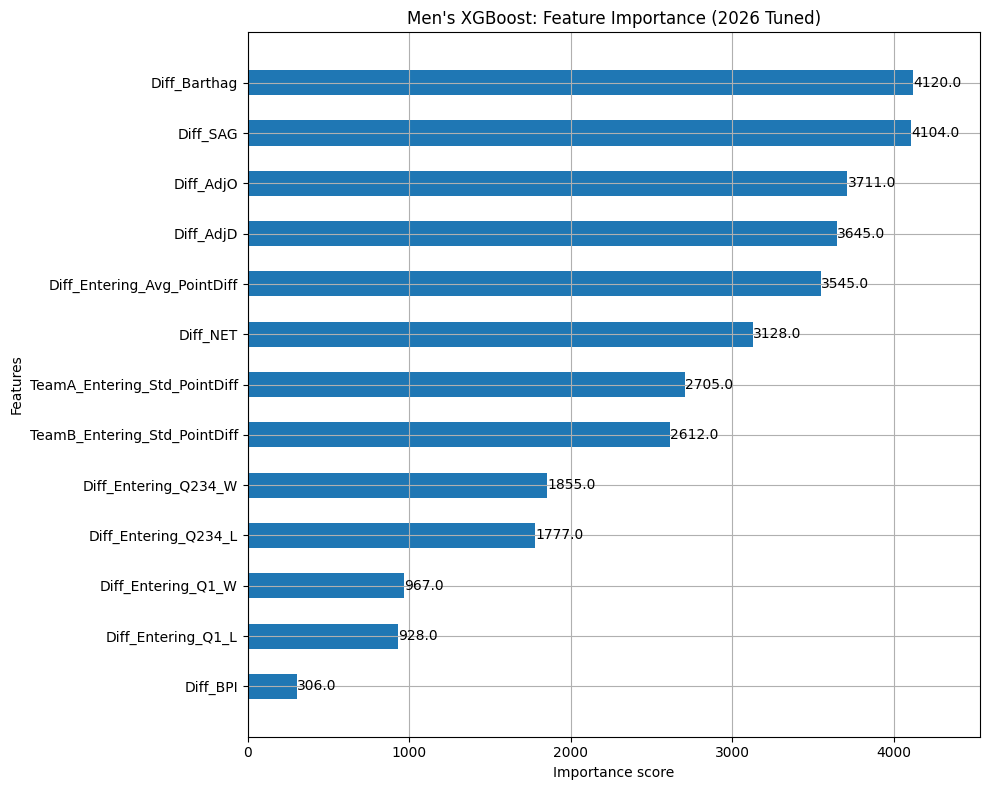

In [1]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import accuracy_score, log_loss
from scipy.stats import norm

print("Loading the Ultimate Regression Dataset...")
m_df = pd.read_csv('ULTIMATE_XGBOOST_TRAINING_DATA.csv')

# Split the data
m_train = m_df[m_df['Season'] <= 2025].copy()
m_valid = m_df[m_df['Season'] == 2026].copy()

drop_cols = ['Season', 'DayNum', 'TeamA_ID', 'TeamB_ID', 'Target', 'ScoreDiff']
X_train_m = m_train.drop(columns=drop_cols)
y_train_spread_m = m_train['ScoreDiff']

X_valid_m = m_valid.drop(columns=drop_cols)
y_valid_spread_m = m_valid['ScoreDiff']
y_valid_binary_m = m_valid['Target']

print("\nInitializing Men's XGBoost Regressor...")
m_model = xgb.XGBRegressor(
    n_estimators=5000, 
    max_depth=4,
    learning_rate=0.02,
    subsample=0.6,
    colsample_bytree=0.6,
    eval_metric='mae',
    early_stopping_rounds=50,
    random_state=45
)

print("Training Model and Validating on 2026 Regular Season...")
m_model.fit(
    X_train_m, y_train_spread_m,
    eval_set=[(X_train_m, y_train_spread_m), (X_valid_m, y_valid_spread_m)],
    verbose=100
)

best_iteration_m = m_model.best_iteration
print(f"\nMen's Model perfectly tuned to the 2026 Meta at Tree {best_iteration_m}!")

# ----- NEW: SAVE MODEL AND METADATA TO DISK -----
m_model.save_model('mens_xgboost_model.json')
joblib.dump({'best_iteration': best_iteration_m}, 'model_meta.pkl')
print("✅ Model and metadata successfully saved to disk!")

# Quick evaluation plot
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(m_model, ax=ax, importance_type='weight', max_num_features=15, height=0.5)
plt.title("Men's XGBoost: Feature Importance (2026 Tuned)")
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from scipy.stats import norm
from sklearn.metrics import mean_squared_error

print("1. Loading Model and Validation Data...")
# Initialize and load the saved model
m_model = xgb.XGBRegressor()
m_model.load_model('mens_xgboost_model.json')
best_iteration_m = joblib.load('model_meta.pkl')['best_iteration']

df = pd.read_csv('ULTIMATE_XGBOOST_TRAINING_DATA.csv')
valid_df = df[df['Season'] == 2026].copy()

drop_cols = ['Season', 'DayNum', 'TeamA_ID', 'TeamB_ID', 'Target', 'ScoreDiff']
X_valid = valid_df.drop(columns=drop_cols, errors='ignore')
y_valid_binary = valid_df['Target']

print("2. Finding the mathematically perfect Standard Deviation Scale...")
m_valid_preds = m_model.predict(X_valid, iteration_range=(0, best_iteration_m + 1))

best_scale = 11.2
best_brier = float('inf')

for s in np.arange(8.0, 15.1, 0.1):
    probs = norm.cdf(m_valid_preds, loc=0, scale=s)
    brier = mean_squared_error(y_valid_binary, probs)
    if brier < best_brier:
        best_brier = brier
        best_scale = s

baseline_brier = mean_squared_error(y_valid_binary, norm.cdf(m_valid_preds, loc=0, scale=11.0))

print(f"   -> Baseline Brier (Scale 11.0): {baseline_brier:.5f}")
print(f"   -> Optimal Brier  (Scale {best_scale:.1f}): {best_brier:.5f}")
print(f"\The math demands we use 'scale={best_scale:.1f}' for the Men's bracket!")

<>:38: SyntaxWarning: invalid escape sequence '\T'
<>:38: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_24382/3352979673.py:38: SyntaxWarning: invalid escape sequence '\T'
  print(f"\The math demands we use 'scale={best_scale:.1f}' for the Men's bracket!")


1. Loading Model and Validation Data...
2. Finding the mathematically perfect Standard Deviation Scale...
   -> Baseline Brier (Scale 11.0): 0.15451
   -> Optimal Brier  (Scale 9.3): 0.15361
\The math demands we use 'scale=9.3' for the Men's bracket!


In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
import joblib
from scipy.stats import norm
from sklearn.metrics import accuracy_score, log_loss

# Load Model
m_model = xgb.XGBRegressor()
m_model.load_model('mens_xgboost_model.json')
best_iteration_m = joblib.load('model_meta.pkl')['best_iteration']

print("Loading Historical NCAA Tournament Games (2022-2024)...")
tourney_df = pd.read_csv('MNCAATourneyDetailedResults.csv')
tourney_df = tourney_df[(tourney_df['Season'] >= 2022) & (tourney_df['Season'] <= 2024)].copy()

np.random.seed(42)
is_team_a_winner = np.random.rand(len(tourney_df)) > 0.5
tourney_df['TeamA_ID'] = np.where(is_team_a_winner, tourney_df['WTeamID'], tourney_df['LTeamID'])
tourney_df['TeamB_ID'] = np.where(is_team_a_winner, tourney_df['LTeamID'], tourney_df['WTeamID'])
tourney_df['Target'] = np.where(is_team_a_winner, 1, 0)
ml_tourney = tourney_df[['Season', 'DayNum', 'TeamA_ID', 'TeamB_ID', 'Target']].copy()

print("Attaching Master Features (Selection Sunday Logic)...")
m_features = pd.read_csv('M_MASTER_FEATURES.csv')
m_final_stats = m_features[m_features['Season'].isin([2022, 2023, 2024])].groupby(['Season', 'TeamID']).tail(1).copy()
m_final_stats.drop(columns=['DayNum'], inplace=True, errors='ignore')

ml_tourney = pd.merge(ml_tourney, m_final_stats, left_on=['Season', 'TeamA_ID'], right_on=['Season', 'TeamID'], how='left')
ml_tourney.rename(columns={col: f'TeamA_{col}' for col in m_final_stats.columns if col not in ['Season', 'TeamID']}, inplace=True)
ml_tourney.drop(columns=['TeamID'], inplace=True)

ml_tourney = pd.merge(ml_tourney, m_final_stats, left_on=['Season', 'TeamB_ID'], right_on=['Season', 'TeamID'], how='left')
ml_tourney.rename(columns={col: f'TeamB_{col}' for col in m_final_stats.columns if col not in ['Season', 'TeamID']}, inplace=True)
ml_tourney.drop(columns=['TeamID'], inplace=True)

diff_metrics = ['AdjO', 'AdjD', 'Barthag', 'Entering_Q1_W', 'Entering_Q1_L', 'Entering_Q234_W', 'Entering_Q234_L', 'Entering_Avg_PointDiff', 'BPI', 'SAG', 'NET']
for stat in diff_metrics:
    if f'TeamA_{stat}' in ml_tourney.columns and f'TeamB_{stat}' in ml_tourney.columns:
        ml_tourney[f'Diff_{stat}'] = ml_tourney[f'TeamA_{stat}'] - ml_tourney[f'TeamB_{stat}']

cols_to_drop = [f'TeamA_{stat}' for stat in diff_metrics] + [f'TeamB_{stat}' for stat in diff_metrics]
ml_tourney.drop(columns=cols_to_drop, inplace=True, errors='ignore')
ml_tourney.fillna(0, inplace=True)

expected_feature_order = [
    'TeamA_Entering_Std_PointDiff', 'TeamB_Entering_Std_PointDiff',
    'Diff_AdjO', 'Diff_AdjD', 'Diff_Barthag',
    'Diff_Entering_Q1_W', 'Diff_Entering_Q1_L',
    'Diff_Entering_Q234_W', 'Diff_Entering_Q234_L',
    'Diff_Entering_Avg_PointDiff',
    'Diff_BPI', 'Diff_SAG', 'Diff_NET'
]

X_tourney = ml_tourney[expected_feature_order]
y_tourney = ml_tourney['Target']

tourney_spreads = m_model.predict(X_tourney, iteration_range=(0, best_iteration_m + 1))
tourney_probs = norm.cdf(tourney_spreads, loc=0, scale=11.2)
tourney_preds = (tourney_spreads > 0).astype(int)

print(f"=====================================")
print(f"  MEN'S MARCH MADNESS BACKTEST (2022-2024)")
print(f"=====================================")
print(f"  Model Accuracy:    {accuracy_score(y_tourney, tourney_preds) * 100:.2f}%")
print(f"  Model Log Loss:    {log_loss(y_tourney, tourney_probs):.4f}")
print(f"=====================================")

Loading Historical NCAA Tournament Games (2022-2024)...
Attaching Master Features (Selection Sunday Logic)...
  MEN'S MARCH MADNESS BACKTEST (2022-2024)
  Model Accuracy:    66.67%
  Model Log Loss:    0.6339


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from scipy.stats import norm

# Load Model
m_model = xgb.XGBRegressor()
m_model.load_model('mens_xgboost_model.json')
best_iteration_m = joblib.load('model_meta.pkl')['best_iteration']

print("Loading Kaggle's Stage 2 Submission Template...")
submission = pd.read_csv('SampleSubmissionStage2.csv')
submission['Season'] = submission['ID'].apply(lambda x: int(x.split('_')[0]))
submission['TeamA_ID'] = submission['ID'].apply(lambda x: int(x.split('_')[1]))
submission['TeamB_ID'] = submission['ID'].apply(lambda x: int(x.split('_')[2]))

print(f"Structuring {len(submission)} Matchups for {submission['Season'].iloc[0]}...")

m_features = pd.read_csv('M_MASTER_FEATURES.csv')
m_final_stats = m_features[m_features['Season'] == 2026].groupby(['Season', 'TeamID']).tail(1).copy()
m_final_stats.drop(columns=['DayNum'], inplace=True, errors='ignore')

submission = pd.merge(submission, m_final_stats, left_on=['Season', 'TeamA_ID'], right_on=['Season', 'TeamID'], how='left')
submission.rename(columns={col: f'TeamA_{col}' for col in m_final_stats.columns if col not in ['Season', 'TeamID']}, inplace=True)
submission.drop(columns=['TeamID'], inplace=True)

submission = pd.merge(submission, m_final_stats, left_on=['Season', 'TeamB_ID'], right_on=['Season', 'TeamID'], how='left')
submission.rename(columns={col: f'TeamB_{col}' for col in m_final_stats.columns if col not in ['Season', 'TeamID']}, inplace=True)
submission.drop(columns=['TeamID'], inplace=True)

for sys in ['BPI', 'SAG', 'NET']:
    submission[f'TeamA_{sys}'] = submission[f'TeamA_{sys}'].fillna(350)
    submission[f'TeamB_{sys}'] = submission[f'TeamB_{sys}'].fillna(350)

diff_metrics = ['AdjO', 'AdjD', 'Barthag', 'Entering_Q1_W', 'Entering_Q1_L', 'Entering_Q234_W', 'Entering_Q234_L', 'Entering_Avg_PointDiff', 'BPI', 'SAG', 'NET']
for stat in diff_metrics:
    if f'TeamA_{stat}' in submission.columns and f'TeamB_{stat}' in submission.columns:
        submission[f'Diff_{stat}'] = submission[f'TeamA_{stat}'] - submission[f'TeamB_{stat}']

submission.fillna(0, inplace=True)

print("Predicting the Men's Bracket...")

expected_feature_order = [
    'TeamA_Entering_Std_PointDiff', 'TeamB_Entering_Std_PointDiff',
    'Diff_AdjO', 'Diff_AdjD', 'Diff_Barthag',
    'Diff_Entering_Q1_W', 'Diff_Entering_Q1_L',
    'Diff_Entering_Q234_W', 'Diff_Entering_Q234_L',
    'Diff_Entering_Avg_PointDiff',
    'Diff_BPI', 'Diff_SAG', 'Diff_NET'
]

X_submit = submission[expected_feature_order]
sub_spreads = m_model.predict(X_submit, iteration_range=(0, best_iteration_m + 1))
submission['Pred'] = norm.cdf(sub_spreads, loc=0, scale=11.2)

final_submission = submission[['ID', 'Pred']]
final_submission.to_csv('mens_stage2_predictions.csv', index=False)

print("\n🏆 SUCCESS! 'mens_stage2_predictions.csv' is ready for Kaggle! 🏆")
display(final_submission.head())

Loading Kaggle's Stage 2 Submission Template...
Structuring 132133 Matchups for 2026...
Predicting the Men's Bracket...

🏆 SUCCESS! 'mens_stage2_predictions.csv' is ready for Kaggle! 🏆


,ID,Pred
0,2026_1101_1102,0.674377
1,2026_1101_1103,0.115382
2,2026_1101_1104,0.008049
3,2026_1101_1105,0.705880
4,2026_1101_1106,0.624210
